<a href="https://colab.research.google.com/github/mohanad-abdalwahab/-/blob/main/HR_full_cleaning_description_notebook_executed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Human Resources Multi-Year Data Pipeline

This notebook reads all uploaded HR Excel files using their exact file names, standardizes heterogeneous schemas across years, performs data cleaning, creates a unified analytical dataset, and generates a comprehensive descriptive profile.

The workflow is designed to be transparent, reproducible, and extensible. It preserves the original files, keeps the source provenance for each row, and exports cleaned outputs for downstream analysis.


In [1]:

from pathlib import Path
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path(".")
YEAR_FILES = [
    "موارد بشرية 2020.xlsx",
    "موارد بشرية 2021.xlsx",
    "موارد بشرية 2022.xlsx",
    "موارد بشرية 2023.xlsx",
    "موارد بشرية 2024.xlsx",
    "موارد بشرية 2025.xlsx",
    "موارد بشرية 2026.xlsx",
]
AUXILIARY_FILE = "محركات عبء العمل إدارة الموارد البشرية .xlsx"

existing_files = [f for f in YEAR_FILES if (DATA_DIR / f).exists()]
missing_files = [f for f in YEAR_FILES if not (DATA_DIR / f).exists()]

print("Detected yearly files:", existing_files)
print("Missing yearly files:", missing_files)
print("Auxiliary file exists:", (DATA_DIR / AUXILIARY_FILE).exists())


Detected yearly files: ['موارد بشرية 2020.xlsx', 'موارد بشرية 2021.xlsx', 'موارد بشرية 2022.xlsx', 'موارد بشرية 2023.xlsx', 'موارد بشرية 2024.xlsx', 'موارد بشرية 2025.xlsx', 'موارد بشرية 2026.xlsx']
Missing yearly files: []
Auxiliary file exists: True


## Helper Functions

In [2]:

canonical_order = ['source_file', 'source_sheet', 'source_year', 'employee_id', 'employee_prev_id', 'national_id', 'job_code', 'position_code', 'job_title', 'job_title_alt', 'org_unit_code', 'org_unit_name', 'section', 'department', 'work_location', 'municipality_or_assistant_undersecretary', 'sector', 'sector_level_2', 'employment_status', 'employee_group', 'employee_subgroup', 'marital_status', 'nationality', 'gender', 'insurance_flag', 'birth_date', 'hire_date', 'action_date', 'org_reassignment_date', 'transfer_from_entity_date', 'action_type', 'action_reason', 'age', 'grade', 'salary_annual', 'currency']

column_aliases = {'م': 'row_number', 'رقم الموظف': 'employee_id', 'رقم الموظف ': 'employee_id', 'رقم الموظف.1': 'employee_id_duplicate', 'رقم الموظف السابق ': 'employee_prev_id', 'رقم الموظف السابق': 'employee_prev_id', 'ر. موظف سابق': 'employee_prev_id', 'الرقم الشخصي ': 'national_id', 'رقم الوظيفي ': 'job_code', 'الوظيفة': 'job_code', 'الوظيفة.2': 'job_code_duplicate', 'المنصب': 'position_code', 'م وظيفي': 'job_code', 'المسمى  الوظيفي ': 'job_title', 'المسمى الوظيفي ': 'job_title', 'المسمى الوظيفي  ': 'job_title', 'المسمى الوظيفي': 'job_title_alt', 'اسم المنصب': 'job_title', 'التعبية الإدارية المباشرة للموظف / الموظفة': 'org_unit_name', 'اسم الوحدة التنظيمية': 'org_unit_name', 'وحدة تنظيمية': 'org_unit_code', 'القسم': 'section', 'الإدارة المباشرة للموظف / الموظفة': 'department', 'الإدارة': 'department', 'الإدارة / البلدية': 'municipality_or_assistant_undersecretary', 'الإدارة/البلدية': 'municipality_or_assistant_undersecretary', 'الوكلاء المساعدين / البلدية': 'municipality_or_assistant_undersecretary', 'الوكيل المساعد / القطاع': 'sector', 'القطاع / الوكيل': 'sector', 'القطاع': 'sector', 'Unnamed: 10': 'sector_level_2', 'القطاع-1': 'sector_level_2', 'مكان العمل': 'work_location', 'اسم': 'employment_status', 'حالة التوظيف': 'employment_status', 'اسم مجموعة الموظفين': 'employee_group', 'اسم المجموعة الفرعية للموظفين': 'employee_subgroup', 'الجنسية': 'nationality', ' الجنس': 'gender', 'نص الجنس': 'gender', 'تاريخ الميلاد': 'birth_date', 'عمر الموظف': 'age', 'العمر ': 'age', 'الدرجة المالية ': 'grade', 'الدرجة ': 'grade', 'الدرجة المالية': 'grade', 'مستوى': 'grade', 'الراتب ': 'salary_annual', 'الراتب': 'salary_annual', 'الراتب السنوي': 'salary_annual', 'العملة': 'currency', 'تاريخ التعين ': 'hire_date', 'تاريخ التعيين ': 'hire_date', 'تعيين': 'hire_date', 'من': 'action_date', 'تاريخ الاجراء': 'action_date', 'اسم نوع الإجراء': 'action_type', 'اسم سبب الإجراء': 'action_reason', 'إعادة التكليف التنظيمي': 'org_reassignment_date', 'تاريخ  إعادة التكليف التنظيمي': 'org_reassignment_date', 'نقل (من هيئة اخرى)': 'transfer_from_entity_date', 'تاريخ  نقل (من هيئة اخرى)': 'transfer_from_entity_date', 'الحالة الاجتماعية': 'marital_status', 'نص L': 'insurance_flag', ' تأمين رقم الموظف': 'insurance_flag', 'السنة ': 'embedded_year', 'Unnamed: 30': 'unnamed_extra'}

date_columns = [
    "birth_date",
    "hire_date",
    "action_date",
    "org_reassignment_date",
    "transfer_from_entity_date",
]

numeric_columns = [
    "employee_id",
    "employee_prev_id",
    "national_id",
    "job_code",
    "position_code",
    "org_unit_code",
    "age",
    "salary_annual",
    "source_year",
]

id_like_columns = [
    "employee_id",
    "employee_prev_id",
    "national_id",
    "job_code",
    "position_code",
    "org_unit_code",
]

text_columns = [
    "job_title",
    "job_title_alt",
    "org_unit_name",
    "section",
    "department",
    "work_location",
    "municipality_or_assistant_undersecretary",
    "sector",
    "sector_level_2",
    "employment_status",
    "employee_group",
    "employee_subgroup",
    "marital_status",
    "nationality",
    "gender",
    "insurance_flag",
    "action_type",
    "action_reason",
    "grade",
    "currency",
]


def make_unique_columns(columns):
    seen = {}
    output = []
    for column in columns:
        count = seen.get(column, 0)
        if count == 0:
            output.append(column)
        else:
            output.append(f"{column}__dup{count}")
        seen[column] = count + 1
    return output

def normalize_header(value):
    if pd.isna(value):
        return value
    value = str(value).replace("\n", " ")
    value = re.sub(r"\s+", " ", value).strip()
    return value

def normalize_text_value(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    value = re.sub(r"\s+", " ", value)
    if value == "":
        return np.nan
    low = value.lower()
    if low in {"nan", "nat", "none", "null", "n/a", "na", "-"}:
        return np.nan
    return value

def extract_year_from_name(file_name):
    match = re.search(r"(20\d{2})", file_name)
    return int(match.group(1)) if match else np.nan

def rename_to_canonical(df):
    normalized_columns = [normalize_header(c) for c in df.columns]
    df = df.copy()
    df.columns = normalized_columns
    renamed = df.rename(columns=column_aliases)
    renamed.columns = make_unique_columns(list(renamed.columns))
    return renamed

def ensure_columns(df, ordered_columns):
    df = df.copy()
    for column in ordered_columns:
        if column not in df.columns:
            df[column] = np.nan
    return df

def first_valid_series(df, candidate_columns):
    extracted = []
    for column in candidate_columns:
        if column in df.columns:
            candidate = df.loc[:, column]
            if isinstance(candidate, pd.DataFrame):
                for subcolumn in candidate.columns:
                    extracted.append(candidate[subcolumn])
            else:
                extracted.append(candidate)
    if not extracted:
        return pd.Series([np.nan] * len(df), index=df.index)
    output = extracted[0].copy()
    for series in extracted[1:]:
        output = output.combine_first(series)
    return output

def standardize_core_fields(df):
    df = df.copy()

    if "employee_id_duplicate" in df.columns:
        df["employee_id"] = first_valid_series(df, ["employee_id", "employee_id_duplicate"])

    if "job_code_duplicate" in df.columns:
        df["job_code"] = first_valid_series(df, ["job_code", "job_code_duplicate"])

    df["job_title"] = first_valid_series(df, ["job_title", "job_title_alt"])
    df["work_location"] = first_valid_series(df, ["work_location", "org_unit_name", "department"])
    df["department"] = first_valid_series(df, ["department", "work_location", "org_unit_name"])
    df["grade"] = first_valid_series(df, ["grade"])
    df["employment_status"] = first_valid_series(df, ["employment_status"])

    for column in text_columns:
        if column in df.columns:
            df[column] = df[column].map(normalize_text_value)

    for column in id_like_columns:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors="coerce").astype("Int64")

    if "source_year" in df.columns:
        df["source_year"] = pd.to_numeric(df["source_year"], errors="coerce").astype("Int64")

    if "embedded_year" in df.columns:
        df["embedded_year"] = pd.to_numeric(df["embedded_year"], errors="coerce").astype("Int64")
        df["source_year"] = df["embedded_year"].combine_first(df["source_year"]).astype("Int64")

    if "salary_annual" in df.columns:
        df["salary_annual"] = pd.to_numeric(df["salary_annual"], errors="coerce")

    if "age" in df.columns:
        df["age"] = pd.to_numeric(df["age"], errors="coerce")

    for column in date_columns:
        if column in df.columns:
            df[column] = pd.to_datetime(df[column], errors="coerce")

    if "age" not in df.columns:
        df["age"] = np.nan

    if "birth_date" in df.columns and "source_year" in df.columns:
        estimated_age = df["source_year"].astype("float") - df["birth_date"].dt.year.astype("float")
        df["age"] = df["age"].fillna(estimated_age)

    if "currency" in df.columns:
        df["currency"] = df["currency"].fillna("QAR")

    return df

def read_single_year_file(file_name):
    file_path = DATA_DIR / file_name
    excel_file = pd.ExcelFile(file_path)
    sheet_name = excel_file.sheet_names[0]
    df_raw = pd.read_excel(file_path, sheet_name=sheet_name)
    df = rename_to_canonical(df_raw)
    df["source_file"] = file_name
    df["source_sheet"] = sheet_name
    df["source_year"] = extract_year_from_name(file_name)
    df = standardize_core_fields(df)
    df = ensure_columns(df, canonical_order)
    leading = canonical_order
    trailing = [c for c in df.columns if c not in leading]
    df = df[leading + trailing]
    return df, df_raw, sheet_name

def missingness_table(df):
    tbl = (
        df.isna()
          .mean()
          .mul(100)
          .round(2)
          .sort_values(ascending=False)
          .rename("missing_pct")
          .reset_index()
          .rename(columns={"index": "column"})
    )
    tbl["non_null_count"] = tbl["column"].map(df.notna().sum())
    tbl["dtype"] = tbl["column"].map(df.dtypes.astype(str))
    return tbl

def top_n_table(df, column, n=10):
    if column not in df.columns:
        return pd.DataFrame(columns=[column, "count", "pct"])
    counts = (
        df[column]
        .fillna("Missing")
        .value_counts(dropna=False)
        .head(n)
        .rename_axis(column)
        .reset_index(name="count")
    )
    counts["pct"] = (counts["count"] / len(df) * 100).round(2)
    return counts

def numeric_profile(df, columns):
    rows = []
    for column in columns:
        if column in df.columns:
            series = pd.to_numeric(df[column], errors="coerce")
            rows.append({
                "column": column,
                "non_null": int(series.notna().sum()),
                "missing": int(series.isna().sum()),
                "mean": series.mean(),
                "median": series.median(),
                "std": series.std(),
                "min": series.min(),
                "q1": series.quantile(0.25),
                "q3": series.quantile(0.75),
                "max": series.max(),
            })
    return pd.DataFrame(rows)

def year_level_summary(df):
    group = df.groupby("source_year", dropna=False)
    out = group.agg(
        rows=("employee_id", "size"),
        distinct_employees=("employee_id", "nunique"),
        avg_age=("age", "mean"),
        median_age=("age", "median"),
        avg_salary=("salary_annual", "mean"),
        median_salary=("salary_annual", "median"),
        min_salary=("salary_annual", "min"),
        max_salary=("salary_annual", "max"),
    ).reset_index()
    return out.sort_values("source_year")

def trim_outliers_iqr(df, columns):
    df = df.copy()
    for column in columns:
        if column in df.columns:
            series = pd.to_numeric(df[column], errors="coerce")
            q1 = series.quantile(0.25)
            q3 = series.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            df[f"{column}_is_outlier_iqr"] = ~series.between(lower, upper, inclusive="both")
    return df

def export_tables_to_excel(path, tables):
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        for sheet_name, table in tables.items():
            safe_name = sheet_name[:31]
            table.to_excel(writer, sheet_name=safe_name, index=False)


## Read All Yearly Files

In [3]:

loaded = {}
raw_snapshots = {}
sheet_lookup = {}

for file_name in existing_files:
    cleaned_df, raw_df, sheet_name = read_single_year_file(file_name)
    loaded[file_name] = cleaned_df
    raw_snapshots[file_name] = raw_df
    sheet_lookup[file_name] = sheet_name

print("Loaded datasets:", list(loaded))
for file_name, df in loaded.items():
    print(file_name, df.shape, "| sheet:", sheet_lookup[file_name])


Loaded datasets: ['موارد بشرية 2020.xlsx', 'موارد بشرية 2021.xlsx', 'موارد بشرية 2022.xlsx', 'موارد بشرية 2023.xlsx', 'موارد بشرية 2024.xlsx', 'موارد بشرية 2025.xlsx', 'موارد بشرية 2026.xlsx']
موارد بشرية 2020.xlsx (248, 40) | sheet: Sheet2
موارد بشرية 2021.xlsx (260, 38) | sheet: Sheet2
موارد بشرية 2022.xlsx (297, 41) | sheet: Sheet2
موارد بشرية 2023.xlsx (241, 36) | sheet: Sheet3
موارد بشرية 2024.xlsx (270, 37) | sheet: Sheet2
موارد بشرية 2025.xlsx (264, 42) | sheet: Sheet1
موارد بشرية 2026.xlsx (273, 37) | sheet: Sheet1


## Raw Schema Review Before Integration

In [4]:

schema_review = []
for file_name, raw_df in raw_snapshots.items():
    schema_review.append({
        "source_file": file_name,
        "sheet_name": sheet_lookup[file_name],
        "rows": raw_df.shape[0],
        "columns": raw_df.shape[1],
        "column_list": " | ".join([str(c) for c in raw_df.columns])
    })

schema_review = pd.DataFrame(schema_review).sort_values("source_file")
schema_review


,source_file,sheet_name,rows,columns,column_list
0,موارد بشرية 2020.xlsx,Sheet2,248,17,م | رقم الموظف | رقم الموظف.1 | التعبية الإدارية المباشرة للموظف / الموظفة | الإدارة المباشرة للموظف / الموظفة | الإ...
1,موارد بشرية 2021.xlsx,Sheet2,260,22,رقم الموظف السابق | رقم الموظف | الرقم الشخصي | المسمى الوظيفي | وحدة تنظيمية | اسم الوحدة التنظيمية | القسم | ال...
2,موارد بشرية 2022.xlsx,Sheet2,297,31,ر. موظف سابق | رقم الموظف | رقم الموظف.1 | الرقم الشخصي | المنصب | المسمى الوظيفي | وحدة تنظيمية | اسم الوحدة التن...
3,موارد بشرية 2023.xlsx,Sheet3,241,23,ر. موظف سابق | رقم الموظف | اسم المنصب | وحدة تنظيمية | اسم الوحدة التنظيمية | اسم | اسم نوع الإجراء | اسم سبب الإجر...
4,موارد بشرية 2024.xlsx,Sheet2,270,28,ر. موظف سابق | رقم الموظف | المسمى الوظيفي | مكان العمل | الإدارة | الوكلاء المساعدين / البلدية | القطاع | القطاع-1...
5,موارد بشرية 2025.xlsx,Sheet1,264,27,رقم الموظف السابق | رقم الموظف | المسمى الوظيفي | مكان العمل | الإدارة | الوكلاء المساعدين / البلدية | القطاع | ح...
6,موارد بشرية 2026.xlsx,Sheet1,273,11,رقم الموظف السابق | رقم الموظف | الإدارة | المسمى الوظيفي | الجنسية | عمر الموظف | تاريخ الميلاد | نص الجنس | الد...


## Build the Unified Longitudinal Dataset

In [5]:

hr = pd.concat(loaded.values(), ignore_index=True, sort=False)

hr["job_title"] = first_valid_series(hr, ["job_title", "job_title_alt"])
hr["employee_id"] = pd.to_numeric(hr["employee_id"], errors="coerce").astype("Int64")
hr["source_year"] = pd.to_numeric(hr["source_year"], errors="coerce").astype("Int64")
hr["salary_annual"] = pd.to_numeric(hr["salary_annual"], errors="coerce")
hr["age"] = pd.to_numeric(hr["age"], errors="coerce")

for column in text_columns:
    if column in hr.columns:
        hr[column] = hr[column].map(normalize_text_value)

hr["record_id"] = np.arange(1, len(hr) + 1)
hr["employee_year_key"] = hr["employee_id"].astype("string") + "_" + hr["source_year"].astype("string")

hr.shape


(1853, 55)

## Cleaning Logic and Quality Enhancements

In [6]:

quality_log = []

before_rows = len(hr)
before_duplicates = hr.duplicated(subset=["employee_id", "source_year"], keep="first").sum()

quality_log.append({"step": "rows_before_cleaning", "value": int(before_rows)})
quality_log.append({"step": "duplicate_employee_year_rows_before", "value": int(before_duplicates)})

hr = hr.drop_duplicates(subset=["employee_id", "source_year"], keep="first").copy()

after_rows = len(hr)
quality_log.append({"step": "rows_after_deduplication", "value": int(after_rows)})

if "gender" in hr.columns:
    hr["gender"] = (
        hr["gender"]
        .replace({
            "ذكر": "Male",
            "أنثى": "Female",
            "انثى": "Female",
            "female": "Female",
            "male": "Male"
        })
    )

if "employment_status" in hr.columns:
    hr["employment_status"] = (
        hr["employment_status"]
        .replace({
            "نشط": "Active"
        })
    )

if "insurance_flag" in hr.columns:
    hr["insurance_flag"] = (
        hr["insurance_flag"]
        .replace({
            "لا": "No",
            "نعم": "Yes"
        })
    )

if "nationality" in hr.columns:
    hr["nationality"] = hr["nationality"].replace({"قطري": "Qatari"})

if "currency" in hr.columns:
    hr["currency"] = hr["currency"].fillna("QAR")

hr["job_title_clean"] = (
    hr["job_title"]
      .astype("string")
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
)

hr["department_clean"] = (
    hr["department"]
      .astype("string")
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
)

hr["salary_band"] = pd.cut(
    hr["salary_annual"],
    bins=[-np.inf, 10000, 20000, 30000, 40000, np.inf],
    labels=["<=10k", "10k-20k", "20k-30k", "30k-40k", ">40k"]
)

hr["age_band"] = pd.cut(
    hr["age"],
    bins=[0, 29, 39, 49, 59, 100],
    labels=["<=29", "30-39", "40-49", "50-59", "60+"]
)

quality_log.append({"step": "duplicate_employee_year_rows_after", "value": int(hr.duplicated(subset=["employee_id", "source_year"]).sum())})
quality_log = pd.DataFrame(quality_log)
quality_log


,step,value
0,rows_before_cleaning,1853
1,duplicate_employee_year_rows_before,0
2,rows_after_deduplication,1853
3,duplicate_employee_year_rows_after,0


## Missingness, Data Types, and Completeness

In [7]:

missing_profile = missingness_table(hr)
missing_profile.head(25)


,column,missing_pct,non_null_count,dtype
0,national_id,100.00,0,float64
1,unnamed_extra,100.00,0,float64
2,تاريخ نقل (من هيئة اخرى),99.84,3,datetime64[ns]
3,تاريخ إعادة التكليف التنظيمي,99.78,4,datetime64[ns]
4,transfer_from_entity_date,99.62,7,datetime64[ns]
5,org_reassignment_date,99.51,9,datetime64[ns]
6,الجنس,86.62,248,object
7,row_number,86.62,248,float64
8,رقم الوظيفي,86.62,248,float64
9,section,85.97,260,object


In [8]:

dtype_profile = (
    pd.DataFrame({
        "column": hr.columns,
        "dtype": hr.dtypes.astype(str).values,
        "non_null": hr.notna().sum().values,
        "nulls": hr.isna().sum().values,
        "null_pct": (hr.isna().mean() * 100).round(2).values
    })
    .sort_values(["null_pct", "column"], ascending=[False, True])
)
dtype_profile.head(30)


,column,dtype,non_null,nulls,null_pct
5,national_id,float64,0,1853,100.00
44,unnamed_extra,float64,0,1853,100.00
50,تاريخ نقل (من هيئة اخرى),datetime64[ns],3,1850,99.84
49,تاريخ إعادة التكليف التنظيمي,datetime64[ns],4,1849,99.78
29,transfer_from_entity_date,datetime64[ns],7,1846,99.62
28,org_reassignment_date,datetime64[ns],9,1844,99.51
36,row_number,float64,248,1605,86.62
39,الجنس,object,248,1605,86.62
38,رقم الوظيفي,float64,248,1605,86.62
12,section,object,260,1593,85.97


## High-Level Descriptive Profile

In [9]:

descriptive_profile = pd.DataFrame([
    {"metric": "Observations", "value": len(hr)},
    {"metric": "Distinct employees", "value": hr["employee_id"].nunique(dropna=True)},
    {"metric": "Distinct years", "value": hr["source_year"].nunique(dropna=True)},
    {"metric": "Distinct departments", "value": hr["department_clean"].nunique(dropna=True)},
    {"metric": "Distinct job titles", "value": hr["job_title_clean"].nunique(dropna=True)},
    {"metric": "Distinct nationalities", "value": hr["nationality"].nunique(dropna=True)},
    {"metric": "Average age", "value": round(hr["age"].mean(), 2)},
    {"metric": "Median age", "value": round(hr["age"].median(), 2)},
    {"metric": "Average salary", "value": round(hr["salary_annual"].mean(), 2)},
    {"metric": "Median salary", "value": round(hr["salary_annual"].median(), 2)},
    {"metric": "Min salary", "value": round(hr["salary_annual"].min(), 2)},
    {"metric": "Max salary", "value": round(hr["salary_annual"].max(), 2)},
])
descriptive_profile


,metric,value
0,Observations,1853.00
1,Distinct employees,412.00
2,Distinct years,7.00
3,Distinct departments,8.00
4,Distinct job titles,307.00
5,Distinct nationalities,27.00
6,Average age,41.43
7,Median age,41.00
8,Average salary,15837.02
9,Median salary,13246.00


## Year-Level Descriptive Statistics

In [10]:

year_summary = year_level_summary(hr)
year_summary


,source_year,rows,distinct_employees,avg_age,median_age,avg_salary,median_salary,min_salary,max_salary
0,2020,248,248,41.741935,41.0,15647.352137,13851.375,2200.0,55000.0
1,2021,260,260,41.257692,41.0,15749.245115,12846.450,2200.0,55000.0
2,2022,297,297,41.178451,41.0,15704.714444,12400.000,2200.0,55000.0
3,2023,241,241,41.502075,42.0,15547.978963,12000.000,2200.0,50000.0
4,2024,270,270,41.277778,42.0,15644.606852,12967.450,2200.0,50000.0
5,2025,264,264,41.647727,42.0,16137.916818,13400.000,2200.0,50000.0
6,2026,273,273,41.443223,42.0,16391.315165,13512.000,2200.0,50000.0


In [11]:

numeric_summary = numeric_profile(hr, ["age", "salary_annual", "source_year"])
numeric_summary


,column,non_null,missing,mean,median,std,min,q1,q3,max
0,age,1853,0,41.427415,41.0,11.557806,18.0,32.0,50.0,104.0
1,salary_annual,1853,0,15837.017329,13246.0,11230.730468,2200.0,7650.0,22400.0,55000.0
2,source_year,1853,0,2023.030221,2023.0,1.992197,2020.0,2021.0,2025.0,2026.0


## Categorical Distributions

### Gender Distribution

In [12]:
top_n_table(hr, 'gender', n=15)

,gender,count,pct
0,Male,678,36.59
1,Female,667,36.00
2,Missing,508,27.42


### Nationality Distribution

In [13]:
top_n_table(hr, 'nationality', n=15)

,nationality,count,pct
0,Qatari,1271,68.59
1,غير قطري,162,8.74
2,مصري,120,6.48
3,هندي,64,3.45
4,إيراني,42,2.27
5,يمني,29,1.57
6,سوداني,26,1.40
7,اردني,20,1.08
8,نيبالي,15,0.81
9,فلسطيني,14,0.76


### Employment Status

In [14]:
top_n_table(hr, 'employment_status', n=15)

,employment_status,count,pct
0,Active,1316,71.02
1,Missing,521,28.12
2,غير نشط,16,0.86


### Employee Group

In [15]:
top_n_table(hr, 'employee_group', n=15)

,employee_group,count,pct
0,قطري,901,48.62
1,Missing,533,28.76
2,وافد,399,21.53
3,خليجي,20,1.08


### Employee Subgroup

In [16]:
top_n_table(hr, 'employee_subgroup', n=15)

,employee_subgroup,count,pct
0,دائم,900,48.57
1,Missing,533,28.76
2,حرفيه و عماليه- وافد,187,10.09
3,داخلي -وافد,134,7.23
4,خارجي-وافد,76,4.10
5,داخلي-خليجي,16,0.86
6,حرفيه و عماليه -خليج,4,0.22
7,منتدب-وافد,2,0.11
8,منتدب,1,0.05


### Top Departments

In [17]:
top_n_table(hr, 'department_clean', n=15)

,department_clean,count,pct
0,إدارة الموارد البشرية,1598,86.24
1,قسم شؤون الموظفين (الموارد البشرية),65,3.51
2,قسم الرواتب والاجور ( المواردالبشرية ),54,2.91
3,إدارة الموارد البشرية (ييئة),49,2.64
4,مكتب المدير ( المواردالبشرية ),31,1.67
5,إدارة الموارد البشرية (الجوازات),23,1.24
6,مساعد مدير إدارة الموارد البشرية,23,1.24
7,وحدة الاسكان (الموارد البشرية),10,0.54


### Top Job Titles

In [18]:
top_n_table(hr, 'job_title_clean', n=15)

,job_title_clean,count,pct
0,فراش رابع,88,4.75
1,خبير شؤون ادارية,39,2.1
2,ملاحظ عمال ملفات خامس,36,1.94
3,استشاري شؤون ادارية اول,34,1.83
4,كاتب شؤون موظفين رابع,31,1.67
5,منسق متابعة ثاني,31,1.67
6,محاسب ثالث,30,1.62
7,خبير شؤون مالية,28,1.51
8,منسق متابعة ثالث,26,1.4
9,عامل ملفات سادس,25,1.35


### Grade Distribution

In [19]:
top_n_table(hr, 'grade', n=15)

,grade,count,pct
0,Missing,298,16.08
1,07,225,12.14
2,06,189,10.20
3,02,147,7.93
4,09,145,7.83
5,13,122,6.58
6,08,112,6.04
7,01,111,5.99
8,03,107,5.77
9,04,89,4.80


### Action Type

In [20]:
top_n_table(hr, 'action_type', n=15)

,action_type,count,pct
0,ترقية بالأقدمية,557,30.06
1,Missing,521,28.12
2,تعيين,335,18.08
3,ازاله تجميد المرتب,155,8.36
4,تعديل وضع وظيفي,95,5.13
5,نقل داخلي,52,2.81
6,العلاوة الدورية,36,1.94
7,الترقيه الاستثنائيه,20,1.08
8,تجميد المرتب,16,0.86
9,مد فترة الخدمة,13,0.70


### Action Reason

In [21]:
top_n_table(hr, 'action_reason', n=15)

,action_reason,count,pct
0,Missing,929,50.13
1,الأقدمية,543,29.30
2,التعيين,269,14.52
3,الحصول على مؤهل دراسي,24,1.30
4,تعديل راتب وشريحة الأجر غ قطري,15,0.81
5,زياده تغيير وضع وظيفي,12,0.65
6,خبرة سابقة,11,0.59
7,زيادة درجة بقرار,10,0.54
8,الاداء,10,0.54
9,حالة خاصة,9,0.49


## Longitudinal Employee Presence Across Years

In [22]:

employee_years = (
    hr.groupby("employee_id", dropna=True)
      .agg(
          first_year=("source_year", "min"),
          last_year=("source_year", "max"),
          years_present=("source_year", "nunique"),
          latest_department=("department_clean", "last"),
          latest_job_title=("job_title_clean", "last"),
          latest_salary=("salary_annual", "last"),
      )
      .reset_index()
      .sort_values(["years_present", "employee_id"], ascending=[False, True])
)

employee_years.head(20)


,employee_id,first_year,last_year,years_present,latest_department,latest_job_title,latest_salary
2,11000038,2020,2026,7,إدارة الموارد البشرية,استشاري شؤون إدارية,39753.00
4,11000069,2020,2026,7,إدارة الموارد البشرية,خبير تطوير اداري اول,34153.00
5,11000071,2020,2026,7,إدارة الموارد البشرية,رئيس فنيين نظم معلومات,31203.00
8,11000107,2020,2026,7,إدارة الموارد البشرية,استشاري شؤون ادارية اول,50000.00
9,11000140,2020,2026,7,إدارة الموارد البشرية,مشرف نظم معلومات ثالث,21303.01
10,11000145,2020,2026,7,إدارة الموارد البشرية,مشرف نظم معلومات ثاني,23003.00
12,11000156,2020,2026,7,إدارة الموارد البشرية,استشاري شؤون ادارية,38753.00
14,11000244,2020,2026,7,إدارة الموارد البشرية,ملاحظ عمال خدمات رابع,14186.90
16,11000281,2020,2026,7,إدارة الموارد البشرية,مندوب متابعة ثاني,14400.00
17,11000339,2020,2026,7,إدارة الموارد البشرية,استشارى شؤون ادارية اول,50000.00


## Outlier Flags for Key Numeric Variables

In [23]:

hr_outlier = trim_outliers_iqr(hr, ["age", "salary_annual"])

outlier_overview = pd.DataFrame({
    "column": ["age", "salary_annual"],
    "outlier_count": [
        int(hr_outlier["age_is_outlier_iqr"].sum()) if "age_is_outlier_iqr" in hr_outlier.columns else 0,
        int(hr_outlier["salary_annual_is_outlier_iqr"].sum()) if "salary_annual_is_outlier_iqr" in hr_outlier.columns else 0
    ],
    "outlier_pct": [
        round(hr_outlier["age_is_outlier_iqr"].mean() * 100, 2) if "age_is_outlier_iqr" in hr_outlier.columns else 0,
        round(hr_outlier["salary_annual_is_outlier_iqr"].mean() * 100, 2) if "salary_annual_is_outlier_iqr" in hr_outlier.columns else 0
    ]
})
outlier_overview


,column,outlier_count,outlier_pct
0,age,21,1.13
1,salary_annual,57,3.08


## Visual Exploration

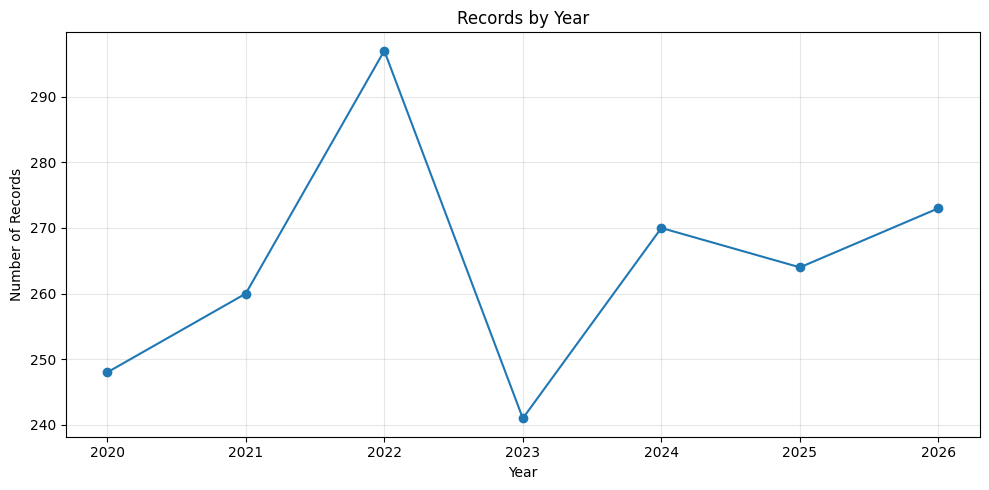

In [24]:

figures_dir = DATA_DIR / "hr_notebook_figures"
figures_dir.mkdir(exist_ok=True)

year_plot = year_summary.copy()

plt.figure(figsize=(10, 5))
plt.plot(year_plot["source_year"], year_plot["rows"], marker="o")
plt.title("Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "records_by_year.png", dpi=160)
plt.show()


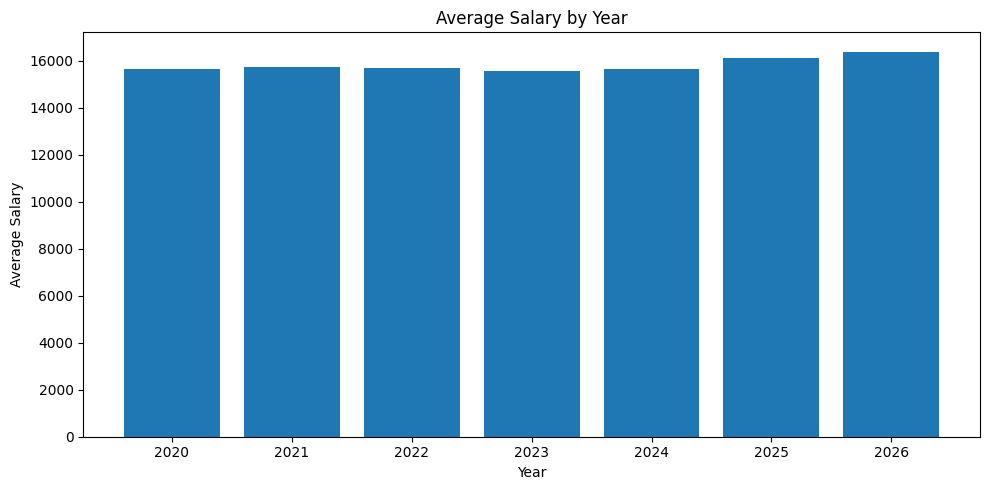

In [25]:

plt.figure(figsize=(10, 5))
plt.bar(year_summary["source_year"].astype(str), year_summary["avg_salary"])
plt.title("Average Salary by Year")
plt.xlabel("Year")
plt.ylabel("Average Salary")
plt.tight_layout()
plt.savefig(figures_dir / "avg_salary_by_year.png", dpi=160)
plt.show()


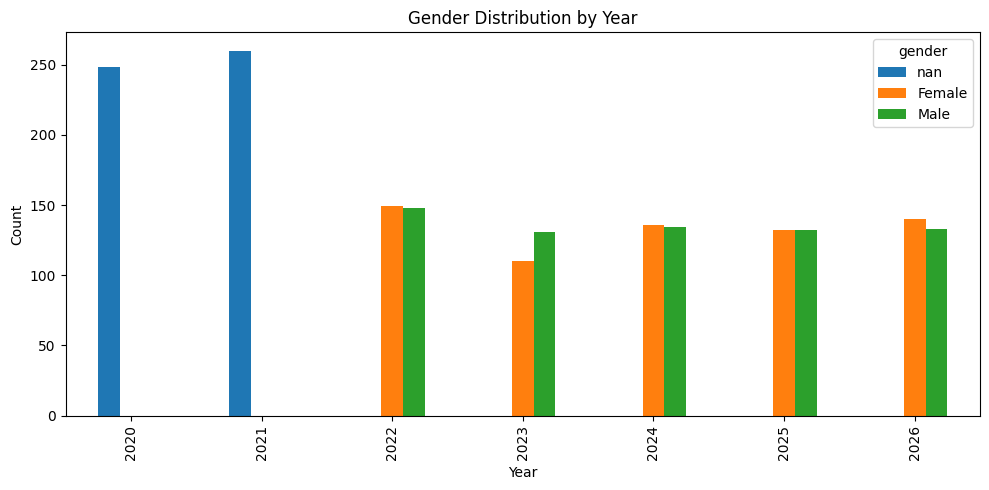

In [26]:

gender_year = (
    hr.groupby(["source_year", "gender"], dropna=False)
      .size()
      .reset_index(name="count")
      .pivot(index="source_year", columns="gender", values="count")
      .fillna(0)
)

gender_year.plot(kind="bar", figsize=(10, 5))
plt.title("Gender Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(figures_dir / "gender_by_year.png", dpi=160)
plt.show()


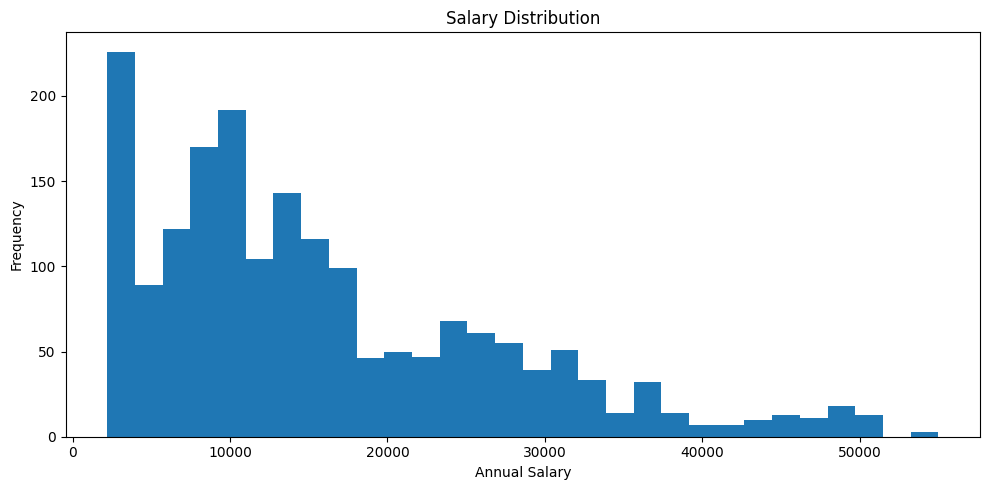

In [27]:

plt.figure(figsize=(10, 5))
hr["salary_annual"].dropna().plot(kind="hist", bins=30)
plt.title("Salary Distribution")
plt.xlabel("Annual Salary")
plt.tight_layout()
plt.savefig(figures_dir / "salary_distribution.png", dpi=160)
plt.show()


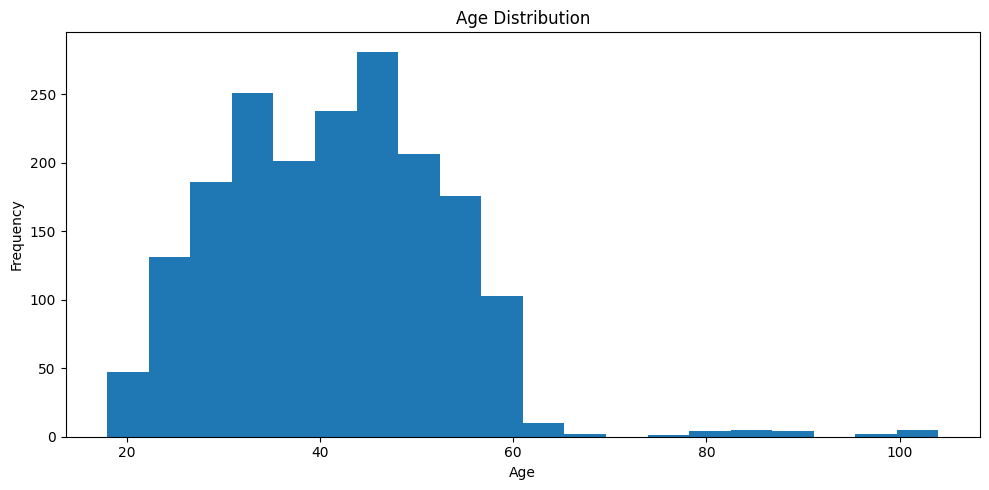

In [28]:

plt.figure(figsize=(10, 5))
hr["age"].dropna().plot(kind="hist", bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.tight_layout()
plt.savefig(figures_dir / "age_distribution.png", dpi=160)
plt.show()


## Auxiliary Workbook Review

The additional workbook is loaded separately as a contextual support file because it contains assumptions and analytical guidance rather than employee-level transactional records.


In [29]:

auxiliary_sheets = {}

if (DATA_DIR / AUXILIARY_FILE).exists():
    aux_excel = pd.ExcelFile(DATA_DIR / AUXILIARY_FILE)
    for sheet_name in aux_excel.sheet_names:
        auxiliary_sheets[sheet_name] = pd.read_excel(DATA_DIR / AUXILIARY_FILE, sheet_name=sheet_name)
    print("Auxiliary sheets:", list(auxiliary_sheets))
else:
    print("Auxiliary file not found.")


Auxiliary sheets: ['الافتراضات', 'طريقة الحساب', 'نموذج التحليل']


In [30]:

auxiliary_preview = []
for sheet_name, df in auxiliary_sheets.items():
    auxiliary_preview.append({
        "sheet_name": sheet_name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "column_names": " | ".join([str(c) for c in df.columns])
    })

auxiliary_preview = pd.DataFrame(auxiliary_preview)
auxiliary_preview


,sheet_name,rows,columns,column_names
0,الافتراضات,27,4,Assumptions | Unnamed: 1 | Unnamed: 2 | Unnamed: 3
1,طريقة الحساب,3,2,نسبة | تكرار
2,نموذج التحليل,206,57,Unnamed: 0 | مراجعة وتحديث محركات عبء العمل (المرحلة الثالثة من برنامج تخطيط القوى العاملة الحكومية) | Unnamed: 2 | ...


In [31]:

for sheet_name, df in auxiliary_sheets.items():
    print("\n" + "=" * 80)
    print(sheet_name)
    display(df.head(10))



الافتراضات


,Assumptions,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,General Assumptions,Duration,Unit,Comments
3,أيام العمل في الأسبوع,5,Days,NaN
4,أيام العمل في السنة,48,Weeks,NaN
5,ساعات العمل العادية في اليوم,7,Hours,NaN
6,ساعات العمل العادية في الأسبوع,35,Hours,NaN
7,ساعات العمل العادية في السنة (من دون احتساب شهر رمضان),1680,Hours,NaN
8,ساعات العمل في شهر رمضان المبارك في اليوم,5,Hours,NaN
9,أسابيع شهر رمضان المبارك,4,Weeks,NaN



طريقة الحساب


,نسبة,تكرار
0,عدد الموظفين/الوحدة,دقائق
1,NaN,ساعات
2,NaN,أيام



نموذج التحليل


,Unnamed: 0,مراجعة وتحديث محركات عبء العمل (المرحلة الثالثة من برنامج تخطيط القوى العاملة الحكومية),Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56
0,NaN,"* للمزيد من الدعم، يرجى الرجوع إلى ""إرشادات مراجعة وتحديث محركات عبء العمل"" (PDF). في حال عدم استلامكم للوثيقة، يرجى...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,المفتاح التوضيحي:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,خلايا مقفولة تحتوي على محركات عبء العمل للمرحلة الثانية من برنامج تخطيط القوى العاملة الحكومية,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,خلايا مدخلات لمحركات عبء العمل الجديدة (حسب الحاجة),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,خلايا مدخلات لمراجعة البيانات وتحديثها (مثل متطلبات الحجم لفترة 2023 - 2029),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,خلايا مدخلات للبيانات الجديدة المطلوبة (مثل متطلبات الحجم لسنة 2030),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,المرحلة الثانية من برنامج تخطيط القوى العاملة الحكومية (2024 - للمرجعية),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,المرحلة الثالثة من برنامج تخطيط القوى العاملة الحكومية (2025 - للمراجعة),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,مبرر تغييرات عبء العمل,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,الحجم,NaN,NaN,NaN,NaN,NaN,NaN,NaN,الوقت/ النسبة,NaN,NaN,NaN,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Export Clean Outputs

In [32]:

output_dir = DATA_DIR / "hr_outputs"
output_dir.mkdir(exist_ok=True)

clean_path_csv = output_dir / "hr_unified_clean.csv"
clean_path_xlsx = output_dir / "hr_unified_clean.xlsx"
profile_path_xlsx = output_dir / "hr_descriptive_outputs.xlsx"
employee_panel_path = output_dir / "hr_employee_panel.csv"

hr.to_csv(clean_path_csv, index=False, encoding="utf-8-sig")
hr.to_excel(clean_path_xlsx, index=False)
employee_years.to_csv(employee_panel_path, index=False, encoding="utf-8-sig")

export_tables_to_excel(
    profile_path_xlsx,
    {
        "descriptive_profile": descriptive_profile,
        "quality_log": quality_log,
        "schema_review": schema_review,
        "missing_profile": missing_profile,
        "dtype_profile": dtype_profile,
        "year_summary": year_summary,
        "numeric_summary": numeric_summary,
        "top_gender": top_n_table(hr, "gender", 20),
        "top_nationality": top_n_table(hr, "nationality", 20),
        "top_department": top_n_table(hr, "department_clean", 20),
        "top_job_title": top_n_table(hr, "job_title_clean", 20),
        "top_grade": top_n_table(hr, "grade", 20),
        "top_action_type": top_n_table(hr, "action_type", 20),
        "top_action_reason": top_n_table(hr, "action_reason", 20),
        "employee_years": employee_years,
    }
)

print("Clean CSV:", clean_path_csv)
print("Clean Excel:", clean_path_xlsx)
print("Employee panel:", employee_panel_path)
print("Descriptive workbook:", profile_path_xlsx)


Clean CSV: hr_outputs/hr_unified_clean.csv
Clean Excel: hr_outputs/hr_unified_clean.xlsx
Employee panel: hr_outputs/hr_employee_panel.csv
Descriptive workbook: hr_outputs/hr_descriptive_outputs.xlsx


In [33]:
# ============================================
# PHASE 2: BUILD FINAL DEPARTMENT-YEAR DATASET
# Append this AFTER your existing cleaning notebook
# ============================================

from pathlib import Path
import re
import numpy as np
import pandas as pd

# ------------------------------------------------
# 0) SETTINGS
# ------------------------------------------------
DATA_DIR = Path(".")
WORKLOAD_FILE = "محركات عبء العمل إدارة الموارد البشرية .xlsx"

OUTPUT_FINAL_CSV = "final_workforce_dataset.csv"
OUTPUT_FINAL_XLSX = "final_workforce_dataset.xlsx"
OUTPUT_HR_DEPTYEAR_CSV = "hr_department_year_features.csv"
OUTPUT_WORKLOAD_CSV = "workload_department_year_features.csv"

# If your notebook already has hr loaded, this will reuse it.
# Otherwise it will fail loudly.
if "hr" not in globals():
    raise ValueError("The dataframe 'hr' is not found. Run your cleaning notebook first.")

# ------------------------------------------------
# 1) BASIC SAFETY CHECKS
# ------------------------------------------------
required_cols = ["employee_id", "source_year"]
for c in required_cols:
    if c not in hr.columns:
        raise ValueError(f"Required column '{c}' not found in hr dataframe.")

# Keep a working copy
hr2 = hr.copy()

# ------------------------------------------------
# 2) STANDARDIZE / CLEAN KEY FIELDS
# ------------------------------------------------
def norm_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)
    if x == "" or x.lower() in {"nan", "none", "null"}:
        return np.nan
    return x

for c in ["department", "department_clean", "job_title", "job_title_clean",
          "gender", "nationality", "employment_status", "action_type",
          "hire_date", "birth_date", "salary_annual", "age", "grade"]:
    if c in hr2.columns and hr2[c].dtype == object:
        hr2[c] = hr2[c].map(norm_text)

# Prefer department_clean if available
if "department_clean" in hr2.columns:
    hr2["department_std"] = hr2["department_clean"]
elif "department" in hr2.columns:
    hr2["department_std"] = hr2["department"]
else:
    hr2["department_std"] = np.nan

# Optional: unify department names manually
# Add/edit mappings here if same department appears with multiple names
department_mapping = {
    "إدارة الموارد البشرية": "إدارة الموارد البشرية",
    "إدارة الموارد البشرية (ييئة)": "إدارة الموارد البشرية",
    "إدارة الموارد البشرية (الجوازات)": "إدارة الموارد البشرية",
    "قسم شؤون الموظفين (الموارد البشرية)": "إدارة الموارد البشرية",
    "قسم الرواتب والاجور ( المواردالبشرية )": "إدارة الموارد البشرية",
    "مكتب المدير ( المواردالبشرية )": "إدارة الموارد البشرية",
    "مساعد مدير إدارة الموارد البشرية": "إدارة الموارد البشرية",
    "وحدة الاسكان (الموارد البشرية)": "إدارة الموارد البشرية",
}

hr2["department_std"] = hr2["department_std"].replace(department_mapping)
hr2["department_std"] = hr2["department_std"].map(norm_text)

# Standardize year
hr2["source_year"] = pd.to_numeric(hr2["source_year"], errors="coerce").astype("Int64")

# Standardize numeric fields
for c in ["age", "salary_annual"]:
    if c in hr2.columns:
        hr2[c] = pd.to_numeric(hr2[c], errors="coerce")

# Standardize dates
for c in ["hire_date", "birth_date", "action_date"]:
    if c in hr2.columns:
        hr2[c] = pd.to_datetime(hr2[c], errors="coerce")

# Fix age if missing and birth_date available
if "birth_date" in hr2.columns:
    age_est = hr2["source_year"].astype("float") - hr2["birth_date"].dt.year.astype("float")
    if "age" not in hr2.columns:
        hr2["age"] = age_est
    else:
        hr2["age"] = hr2["age"].fillna(age_est)

# Remove impossible ages
if "age" in hr2.columns:
    hr2.loc[(hr2["age"] < 18) | (hr2["age"] > 65), "age"] = np.nan

# ------------------------------------------------
# 3) BINARY / GROUP FEATURES
# ------------------------------------------------
# Gender
if "gender" in hr2.columns:
    hr2["gender_std"] = hr2["gender"].replace({
        "ذكر": "Male", "Male": "Male", "male": "Male",
        "أنثى": "Female", "انثى": "Female", "Female": "Female", "female": "Female"
    })
else:
    hr2["gender_std"] = np.nan

# Nationality -> Qatari vs Non_Qatari
if "nationality" in hr2.columns:
    qatari_values = {"قطري", "Qatari", "وثيقة قطري"}
    hr2["nationality_group"] = np.where(hr2["nationality"].isin(qatari_values), "Qatari", "Non_Qatari")
    hr2.loc[hr2["nationality"].isna(), "nationality_group"] = np.nan
else:
    hr2["nationality_group"] = np.nan

# Employment status -> Active flag
if "employment_status" in hr2.columns:
    active_values = {"نشط", "Active", "فعال"}
    hr2["is_active"] = hr2["employment_status"].isin(active_values).astype(int)
else:
    hr2["is_active"] = 1  # fallback

# Education (only if a recognized column exists)
education_col = None
for candidate in ["education_level", "qualification", "degree", "المؤهل", "الشهادة"]:
    if candidate in hr2.columns:
        education_col = candidate
        break

if education_col is not None:
    hr2["education_std"] = hr2[education_col].map(norm_text)
else:
    hr2["education_std"] = np.nan

# ------------------------------------------------
# 4) EVENT FLAGS FROM ACTION TYPES
# ------------------------------------------------
def contains_any(series, keywords):
    s = series.fillna("").astype(str)
    pattern = "|".join([re.escape(k) for k in keywords])
    return s.str.contains(pattern, case=False, regex=True)

if "action_type" not in hr2.columns:
    hr2["action_type"] = np.nan

hr2["is_hire"] = contains_any(hr2["action_type"], ["تعيين"]).astype(int)

hr2["is_promotion"] = contains_any(
    hr2["action_type"],
    ["ترقية", "الترقيه", "ترقية بالأقدمية", "الترقيه الاستثنائيه"]
).astype(int)

hr2["is_transfer_in"] = contains_any(
    hr2["action_type"],
    ["نقل (من هيئة اخرى)", "نقل من هيئة اخرى", "إنتداب خارجي-منتدب إلي"]
).astype(int)

hr2["is_transfer_out"] = contains_any(
    hr2["action_type"],
    ["نقل داخلي", "إعادة التكليف التنظيمي", "انتداب جزئي", "العودة من الانتداب"]
).astype(int)

hr2["is_retirement"] = contains_any(
    hr2["action_type"],
    ["تقاعد", "إحالة إلى التقاعد", "انهاء خدمة للتقاعد", "مد فترة الخدمة"]
).astype(int)

# If retirement eligibility rule exists in your organization, edit it here.
# For now, a practical proxy:
# age >= 60 OR grade/other rule if known later.
hr2["is_retirement_eligible"] = np.where(hr2["age"] >= 60, 1, 0)

# ------------------------------------------------
# 5) DERIVED FEATURES
# ------------------------------------------------
# Years of service
if "hire_date" in hr2.columns:
    # Approximate service years at the end of source_year
    ref_date = pd.to_datetime(hr2["source_year"].astype(str) + "-12-31", errors="coerce")
    hr2["years_of_service"] = (ref_date - hr2["hire_date"]).dt.days / 365.25
    hr2.loc[hr2["years_of_service"] < 0, "years_of_service"] = np.nan
else:
    hr2["years_of_service"] = np.nan

# Salary
if "salary_annual" not in hr2.columns:
    hr2["salary_annual"] = np.nan

# ------------------------------------------------
# 6) BUILD HR DEPARTMENT-YEAR FEATURES
# ------------------------------------------------
group_cols = ["department_std", "source_year"]

# Keep only rows with department and year
hr3 = hr2[hr2["department_std"].notna() & hr2["source_year"].notna()].copy()

# Base aggregation
dept_year_hr = (
    hr3.groupby(group_cols)
       .agg(
           Total_Employees=("employee_id", "nunique"),
           Active_Employees_Count=("is_active", "sum"),
           Male_Count=("gender_std", lambda s: (s == "Male").sum()),
           Female_Count=("gender_std", lambda s: (s == "Female").sum()),
           Qatari_Count=("nationality_group", lambda s: (s == "Qatari").sum()),
           Non_Qatari_Count=("nationality_group", lambda s: (s == "Non_Qatari").sum()),
           Avg_Age=("age", "mean"),
           Avg_Years_of_Service=("years_of_service", "mean"),
           Age_50_Plus_Count=("age", lambda s: (s >= 50).sum()),
           Age_55_Plus_Count=("age", lambda s: (s >= 55).sum()),
           Retirement_Eligible_Count=("is_retirement_eligible", "sum"),
           Retirements_Count=("is_retirement", "sum"),
           New_Hires_Count=("is_hire", "sum"),
           Promotions_Count=("is_promotion", "sum"),
           Transfers_In_Count=("is_transfer_in", "sum"),
           Transfers_Out_Count=("is_transfer_out", "sum"),
           Avg_Annual_Salary=("salary_annual", "mean"),
           Total_Annual_Salary=("salary_annual", "sum"),
       )
       .reset_index()
)

dept_year_hr["Retirement_Eligible_Rate"] = np.where(
    dept_year_hr["Total_Employees"] > 0,
    dept_year_hr["Retirement_Eligible_Count"] / dept_year_hr["Total_Employees"],
    np.nan
)

# Optional education counts if available
if hr3["education_std"].notna().any():
    edu = hr3.copy()
    edu["Bachelor_Flag"] = edu["education_std"].fillna("").str.contains("بكالوريوس|Bachelor", case=False, regex=True).astype(int)
    edu["Master_Flag"] = edu["education_std"].fillna("").str.contains("ماجستير|Master", case=False, regex=True).astype(int)
    edu["PhD_Flag"] = edu["education_std"].fillna("").str.contains("دكتوراه|PhD|Doctor", case=False, regex=True).astype(int)

    edu_agg = (
        edu.groupby(group_cols)
           .agg(
               Bachelor_Count=("Bachelor_Flag", "sum"),
               Master_Count=("Master_Flag", "sum"),
               PhD_Count=("PhD_Flag", "sum"),
           )
           .reset_index()
    )

    dept_year_hr = dept_year_hr.merge(edu_agg, on=group_cols, how="left")
else:
    dept_year_hr["Bachelor_Count"] = np.nan
    dept_year_hr["Master_Count"] = np.nan
    dept_year_hr["PhD_Count"] = np.nan

# Add a simple department code
dept_codes = {d: f"D{str(i+1).zfill(2)}" for i, d in enumerate(sorted(dept_year_hr["department_std"].dropna().unique()))}
dept_year_hr["Department_Code"] = dept_year_hr["department_std"].map(dept_codes)

# Rename for final clarity
dept_year_hr = dept_year_hr.rename(columns={
    "department_std": "Department",
    "source_year": "Year"
})

# Reorder
hr_cols_order = [
    "Year", "Department", "Department_Code",
    "Total_Employees", "Active_Employees_Count",
    "Male_Count", "Female_Count",
    "Qatari_Count", "Non_Qatari_Count",
    "Avg_Age", "Avg_Years_of_Service",
    "Age_50_Plus_Count", "Age_55_Plus_Count",
    "Retirement_Eligible_Count", "Retirement_Eligible_Rate", "Retirements_Count",
    "New_Hires_Count", "Promotions_Count", "Transfers_In_Count", "Transfers_Out_Count",
    "Bachelor_Count", "Master_Count", "PhD_Count",
    "Avg_Annual_Salary", "Total_Annual_Salary"
]
dept_year_hr = dept_year_hr[[c for c in hr_cols_order if c in dept_year_hr.columns]]

# ------------------------------------------------
# 7) READ + STANDARDIZE WORKLOAD FILE
# ------------------------------------------------
if not (DATA_DIR / WORKLOAD_FILE).exists():
    raise FileNotFoundError(f"Workload file not found: {WORKLOAD_FILE}")

workbook = pd.ExcelFile(DATA_DIR / WORKLOAD_FILE)
workload_sheets = workbook.sheet_names

workload_frames = []
for sh in workload_sheets:
    tmp = pd.read_excel(DATA_DIR / WORKLOAD_FILE, sheet_name=sh)
    tmp["source_sheet"] = sh
    workload_frames.append(tmp)

workload_raw = pd.concat(workload_frames, ignore_index=True, sort=False)
workload_raw.columns = [norm_text(c) for c in workload_raw.columns]

# Candidate column mapping — edit only if your actual columns differ
def find_column(df, candidates):
    cols = {str(c).strip(): c for c in df.columns}
    for cand in candidates:
        for actual in df.columns:
            if str(actual).strip() == cand:
                return actual
    for cand in candidates:
        for actual in df.columns:
            if cand.lower() in str(actual).lower():
                return actual
    return None

department_col = find_column(workload_raw, ["الإدارة", "الادارة", "Department"])
driver_col = find_column(workload_raw, ["محرك عبء العمل", "محرك العمل", "Workload Driver"])
calc_result_col = find_column(workload_raw, ["النتيجة", "نتيجة", "Workforce_Demand", "الاحتياج", "عدد الموظفين المطلوب"])

# Try to detect year columns automatically: 2020..2026
year_cols = {}
for y in range(2020, 2027):
    for c in workload_raw.columns:
        if str(y) == str(c).strip():
            year_cols[y] = c
            break
        if str(y) in str(c):
            year_cols[y] = c
            break

if department_col is None:
    raise ValueError("Could not detect workload department column automatically.")

if len(year_cols) == 0:
    raise ValueError("Could not detect workload year columns automatically (2020-2026).")

# Standardize department names
workload_raw["Department"] = workload_raw[department_col].map(norm_text)
workload_raw["Department"] = workload_raw["Department"].replace(department_mapping)

# Melt yearly values
melt_parts = []
for y, c in year_cols.items():
    part = workload_raw[["Department"]].copy()
    part["Year"] = y
    part["Workload_Total"] = pd.to_numeric(workload_raw[c], errors="coerce")
    if driver_col is not None:
        part["Workload_Driver"] = workload_raw[driver_col].map(norm_text)
    else:
        part["Workload_Driver"] = np.nan
    if calc_result_col is not None:
        # If result column is non-year-specific and repeated per row, keep it.
        # If your file has year-specific result columns, replace this logic later.
        part["Workforce_Demand_Row"] = pd.to_numeric(workload_raw[calc_result_col], errors="coerce")
    else:
        part["Workforce_Demand_Row"] = np.nan
    melt_parts.append(part)

workload_long = pd.concat(melt_parts, ignore_index=True)

# Aggregate workload by department-year
dept_year_workload = (
    workload_long.groupby(["Department", "Year"], dropna=False)
        .agg(
            Workload_Driver_Count=("Workload_Driver", lambda s: s.nunique(dropna=True)),
            Workload_Total=("Workload_Total", "sum"),
            Workload_Result_Total=("Workforce_Demand_Row", "sum"),
        )
        .reset_index()
)

# Main target
dept_year_workload["Workforce_Demand"] = dept_year_workload["Workload_Result_Total"]
# fallback if result column absent
dept_year_workload["Workforce_Demand"] = dept_year_workload["Workforce_Demand"].fillna(dept_year_workload["Workload_Total"])

# ------------------------------------------------
# 8) MERGE HR + WORKLOAD
# ------------------------------------------------
final_df = dept_year_hr.merge(
    dept_year_workload,
    on=["Department", "Year"],
    how="outer"
)

# Fill Department_Code if missing
if "Department_Code" not in final_df.columns:
    final_df["Department_Code"] = final_df["Department"].map(dept_codes)
else:
    final_df["Department_Code"] = final_df["Department_Code"].fillna(final_df["Department"].map(dept_codes))

# Workforce gap
final_df["Workforce_Gap"] = final_df["Workforce_Demand"] - final_df["Total_Employees"]

# Sort
final_df = final_df.sort_values(["Department", "Year"]).reset_index(drop=True)

# ------------------------------------------------
# 9) OPTIONAL: FILL SMALL GAPS FOR MODELING
# ------------------------------------------------
# Do not aggressively impute here; keep it conservative.
num_cols = final_df.select_dtypes(include=[np.number]).columns.tolist()

# Example: if count fields are missing after outer merge, set them to 0 only when sensible
count_like_cols = [
    "Total_Employees", "Active_Employees_Count", "Male_Count", "Female_Count",
    "Qatari_Count", "Non_Qatari_Count", "Age_50_Plus_Count", "Age_55_Plus_Count",
    "Retirement_Eligible_Count", "Retirements_Count",
    "New_Hires_Count", "Promotions_Count", "Transfers_In_Count", "Transfers_Out_Count",
    "Bachelor_Count", "Master_Count", "PhD_Count",
    "Workload_Driver_Count"
]

for c in count_like_cols:
    if c in final_df.columns:
        final_df[c] = final_df[c].fillna(0)

# ------------------------------------------------
# 10) EXPORT
# ------------------------------------------------
dept_year_hr.to_csv(OUTPUT_HR_DEPTYEAR_CSV, index=False, encoding="utf-8-sig")
dept_year_workload.to_csv(OUTPUT_WORKLOAD_CSV, index=False, encoding="utf-8-sig")
final_df.to_csv(OUTPUT_FINAL_CSV, index=False, encoding="utf-8-sig")
final_df.to_excel(OUTPUT_FINAL_XLSX, index=False)

print("Saved HR department-year features:", OUTPUT_HR_DEPTYEAR_CSV)
print("Saved Workload department-year features:", OUTPUT_WORKLOAD_CSV)
print("Saved FINAL modeling dataset:", OUTPUT_FINAL_CSV)
print("Saved FINAL modeling dataset (Excel):", OUTPUT_FINAL_XLSX)

print("\nFinal dataset shape:", final_df.shape)
display(final_df.head(20))

ValueError: Could not detect workload department column automatically.

## Final Analytical Notes

This notebook intentionally standardizes a changing schema across years. That means the unified table is analytically useful, but some fields are structurally absent in certain years because they do not exist in the source files themselves. The source provenance columns preserve traceability for every row and make it easy to filter analyses by original file and original sheet.

Recommended next extensions:
1. Build workforce transition indicators such as joiners, leavers, and stayers between adjacent years.
2. Add pay progression analysis at employee level.
3. Add cohort tracking by department, grade, and job family.
4. Add automated validation rules for impossible dates or age-salary anomalies.
